# Model exploration notebook

> This notebook is dedicated to comparing candidate super-resolution architectures, validating the bicubic baseline, justifying implementation choices, and defining a feasible training strategy within project hardware constraints.

## Candidate models overview

We propose following candidate models for our universal image upscaler:
- A non-learned baseline (bicubic interpolation).
- A lightweight CNN (SRCNN).
- An intermediate GAN (SRGAN)
- An enhanced CNN (EDSR).
- SoTA GAN model (Real-ESRGAN).
- SoTA Transformer model (SwinIR).

We evaluate each model’s architecture, training feasibility, computational demands, and alignment with our evaluation metrics (PSNR, SSIM).

Now, let's take a closer look at each of our candidates.

### Bicubic Interpolation (Baseline)

Bicubic interpolation requires no training and serves as the minimal benchmark all neural approaches must surpass. It is also used as a degradation operator (HR -> LR).

- Strengths: fast, deterministic, standard in SR literature.
- Limitations: blurry results.

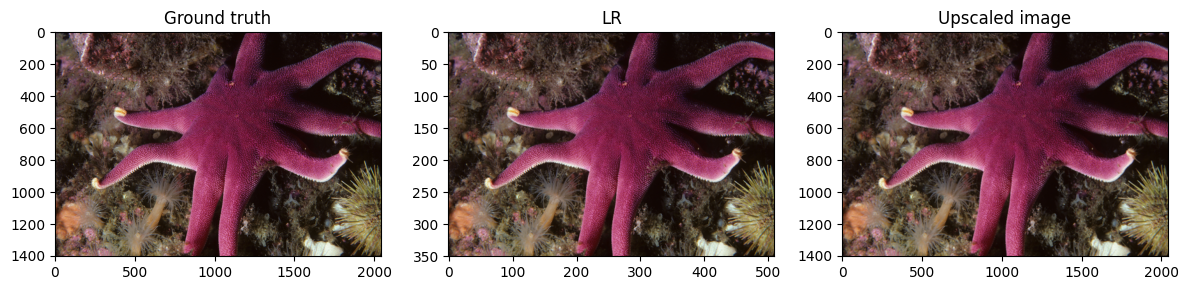

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# Scaling up to x4
SCALE = 4

# Original image
img = Image.open("../data/div2k_samples/0001.png").convert("RGB")
w, h = img.size

# Cropped original image is our ground truth
hr_img = img.crop((0, 0, w // SCALE * SCALE, h // SCALE * SCALE))

# Downscaling image
lr_img = hr_img.resize((hr_img.width // SCALE, hr_img.height // SCALE), Image.Resampling.BICUBIC)

# Upscaling it back from LR
upscaled_img = lr_img.resize((lr_img.width * SCALE, lr_img.height * SCALE), Image.Resampling.BICUBIC)

# Visualizing all three
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
# Ground truth
ax1.imshow(hr_img)
ax1.set_title("Ground truth")

# LR image
ax2.imshow(lr_img)
ax2.set_title("LR")

# Upscaled image
ax3.imshow(upscaled_img)
ax3.set_title("Upscaled image")

plt.tight_layout()
plt.show()

It is, however, problematic to see any differences between full images, so we will zoom in a bit.

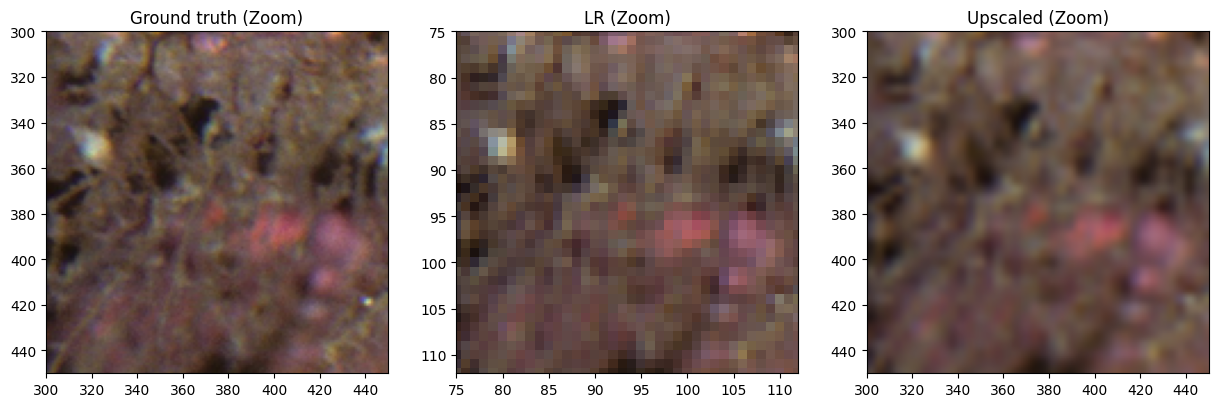

In [2]:
# Coords, where to zoom
x, y = 300, 300
size = 150  # size of a "zoom square"

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(hr_img)
ax1.set_title("Ground truth (Zoom)")

ax2.imshow(lr_img)
ax2.set_title(f"LR (Zoom)")

ax3.imshow(upscaled_img)
ax3.set_title("Upscaled (Zoom)")

# Zoom for ground truth and upscaled versions since they are identical in size
for ax in [ax1, ax3]:
    ax.set_xlim(x, x + size)
    ax.set_ylim(y + size, y)

# Low resolution image needs additional scaling factor since its smaller
ax2.set_xlim(x // SCALE, (x + size) // SCALE)
ax2.set_ylim((y + size) // SCALE, y // SCALE)

plt.show()

As we can see, upscaled image is blurry, but it has significantly better quality when compared to LR one.

Last but not least, we use PSNR and SSIM metrics to mathematically measure how closely the reconstructed image matches the original ground truth.

In [3]:
from skimage.metrics import peak_signal_noise_ratio as PSNR
from skimage.metrics import structural_similarity as SSIM
import numpy as np


# Typecast from Image to ndarray
hr_img, upscaled_img = np.array(hr_img), np.array(upscaled_img)

print(f"PSNR: {PSNR(hr_img, upscaled_img)} dB")
print(f"SSIM: {SSIM(hr_img, upscaled_img, channel_axis=-1)}")

PSNR: 28.54553204735012 dB
SSIM: 0.7900476087087845


**Results interpretation**

- PSNR ~28.5: this value indicates a moderate level of reconstruction quality. Typically, a PSNR below 30 dB typically reflects perceptible blurring and a loss of high-frequency details.
- SSIM ~0.79: this score suggests that approximately 79% of the structural information, luminance, and contrast from the original image was preserved.


Overall, the baseline did well; it forms a solid foundation for further comparison with machine learning-based models.

### SRCNN

**SRCNN** (Super-Resolution Convolutional Neural Network) is a deep learning model designed for single-image super-resolution (SISR).

Introduced in 2014, it was the first method to demonstrate that a convolutional neural network could be used to map low-resolution images to high-resolution ones end-to-end, significantly outperforming traditional interpolation methods.

The SRCNN architecture is intentionally simple yet powerful, consisting of three main stages that mimic the traditional sparse-coding-based reconstruction process:
  1.  **Patch Extraction and Representation**: this first layer extracts a set of feature maps from the low-resolution input.
  2.  **Non-linear Mapping**: this middle layer maps the high-dimensional feature vectors onto another set of high-dimensional vectors, representing the high-resolution patches.
  3.  **Reconstruction**: the final layer aggregates the patch-wise representations to generate the final high-resolution image.

This end-to-end mapping is implemented using a fully convolutional network. Below is a standard implementation using PyTorch:

```py
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        # Patch extraction
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        # Non-linear mapping
        self.conv2 = nn.Conv2d(64, 32, kernel_size=1, padding=0)
        # Reconstruction
        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x
```

The **hyperparameters** used in this implementation (often referred to as the 9-1-5 configuration) were optimized by the authors for the best balance between performance and speed:

1. **Filter Sizes (9, 1, 5)**:
  - The $ 9 \times 9 $ kernel in the first layer is large enough to capture sufficient local context from the input.
  - The $ 1 \times 1 $ kernel in the second layer performs a non-linear mapping of the 64-dimensional features into a 32-dimensional space, acting as a point-wise transformation.
  - The $ 5 \times 5 $ kernel in the last layer helps smooth out the reconstructed pixels into a cohesive high-resolution image.

2. **Filter Counts (64, 32)**: using 64 and 32 filters provides enough capacity to learn complex textures without making the model too computationally expensive for 2014 hardware.

3. **Single Channel (1)**: the model is trained on the Y channel (luminance) of the YCbCr color space. This is because humans are more sensitive to brightness details than to color (chrominance) details, making it more efficient to focus the network's learning power there. Therefore, we will focus on training our model specifically on the Y channel, while the color components (Cb and Cr) will be handled separately using standard bicubic interpolation.

Since this architecture is considered as a lightweight one, we will train it from scratch. 

### SRGAN (Super-Resolution Generative Adversarial Network)

SRGAN introduces a **Generative Adversarial Network (GAN)** framework to super-resolution. Unlike previous CNN-based methods that optimize for pixel-wise accuracy (like MSE), SRGAN optimizes for perceptual quality.